# Paper Plots - KDE UMAP (MEL)

This notebook generates publication-ready KDE plots from all `kde_data__*.csv` files in `kde umap`.

For each dataset, it exports two variants:
- `with_title`
- `without_title`

Each variant is saved as **PNG**, **SVG**, and **PDF**.

## 1) Imports and Style

In [12]:
from __future__ import annotations

from pathlib import Path
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 400,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.titlesize": 21,
    "axes.labelsize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 2) Configuration (Editable)

In [13]:
PROJECT_ROOT = Path.cwd()

CANDIDATE_DATA_DIRS = [
    PROJECT_ROOT / "kde umap",
    PROJECT_ROOT / "Version 2" / "kde umap",
    PROJECT_ROOT.parent / "Version 2" / "kde umap",
]

DATA_DIR = next((path.resolve() for path in CANDIDATE_DATA_DIRS if path.exists()), CANDIDATE_DATA_DIRS[0].resolve())
OUTPUT_DIR = DATA_DIR.parent / "paper_figures" / "kde"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ORDERED_KDE_FILES = [
    "kde_data__Relevance.csv",
    "kde_data__Interpretability.csv",
    "kde_data__Completeness.csv",
    "kde_data__Differential_Regime.csv",
    "kde_data__Discretionality.csv",
    "kde_data__risk_score.csv",
]

TARGET_TITLE_PREFIX = {
    "Relevance": "a",
    "Interpretability": "b",
    "Completeness": "c",
    "Differential Regime": "d",
    "Discretionality": "e",
    "Risk Score > 4.5": "f",
}

TARGET_DISPLAY_NAME = {
    "Interpretability": "Interpretation",
    "Discretionality": "Discretion",
}

GREEN_COLOR = "#1B9E77"
RED_COLOR = "#AC2B72"
GRAY_COLOR = "#9E9E9E"

RISK_SCORE_THRESHOLD = 4.5

FIGSIZE_SINGLE = (6.8, 5.2)
EXPORT_DPI = 400

TITLE_FONT_SIZE = 21
AXIS_LABEL_FONT_SIZE = 13
TICK_LABEL_FONT_SIZE = 12
LEGEND_FONT_SIZE = 14

POINT_SIZE_GRAY = 20
POINT_SIZE_COLOR = 22
POINT_ALPHA_GRAY = 0.30
POINT_ALPHA_COLOR = 0.55

KDE_LEVELS = 10
KDE_ALPHA_FILL = 0.24
KDE_LINEWIDTH = 1.2
KDE_THRESH = 0.05
KDE_BW_ADJUST = 1.05

print("CWD:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

CWD: c:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2
DATA_DIR: C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\kde umap
OUTPUT_DIR: C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\kde


## 3) Utility Functions

In [14]:
def resolve_kde_file(file_name: str) -> Path:
    candidates = [
        DATA_DIR / file_name,
        PROJECT_ROOT / file_name,
        PROJECT_ROOT / "kde umap" / file_name,
        PROJECT_ROOT / "Version 2" / "kde umap" / file_name,
        PROJECT_ROOT.parent / "Version 2" / "kde umap" / file_name,
    ]

    seen = set()
    ordered = []
    for c in candidates:
        key = str(c)
        if key not in seen:
            seen.add(key)
            ordered.append(c)

    for c in ordered:
        if c.exists():
            return c.resolve()

    tried = "\n- ".join(str(c) for c in ordered)
    raise FileNotFoundError(f"Missing file: {file_name}\nTried:\n- {tried}")


def display_name(target_name: str) -> str:
    return TARGET_DISPLAY_NAME.get(target_name, target_name)


def format_target_title(target_name: str) -> str:
    prefix = TARGET_TITLE_PREFIX.get(target_name)
    shown = display_name(target_name)
    return f"{prefix}) {shown}" if prefix else shown


def build_meta(file_name: str) -> dict:
    raw = file_name.replace("kde_data__", "").replace(".csv", "")

    if raw == "risk_score":
        target_name = "Risk Score > 4.5"
        return {
            "file_name": file_name,
            "target_name": target_name,
            "base_stem": "kde_mel_umap__risk_score_gt_4_5",
            "legend_labels": {
                "color": f"Risk Score > {RISK_SCORE_THRESHOLD}",
                "gray": f"Risk Score <= {RISK_SCORE_THRESHOLD}",
            },
            "is_risk_score": True,
        }

    target_name = raw.replace("_", " ")
    legend_labels = {
        "color": "True (1)",
        "gray": "False (0)",
    }

    if target_name == "Interpretability":
        legend_labels = {
            "color": "Medium/High (2-3)",
            "gray": "Low (1)",
        }

    return {
        "file_name": file_name,
        "target_name": target_name,
        "base_stem": f"kde_mel_umap__{raw}",
        "legend_labels": legend_labels,
        "is_risk_score": False,
    }


def _group_from_raw(group_value: str, target_value: float | int | None, target_name: str) -> str:
    s = str(group_value).strip().lower()
    if "color" in s:
        return "color"
    if "gray" in s or "grey" in s:
        return "gray"

    # Fallback from numeric value when group text is unavailable.
    if target_name == "Interpretability":
        return "color" if pd.notna(target_value) and int(target_value) in (2, 3) else "gray"

    return "color" if pd.notna(target_value) and int(target_value) == 1 else "gray"


def prepare_kde_dataframe(meta: dict) -> pd.DataFrame:
    path = resolve_kde_file(meta["file_name"])
    df = pd.read_csv(path).copy()

    if meta["is_risk_score"]:
        required = {"umap_x", "umap_y", "Risk Score"}
        missing = required - set(df.columns)
        if missing:
            raise ValueError(f"{meta['file_name']} missing columns: {sorted(missing)}")

        df["group_key"] = df["Risk Score"].apply(lambda v: "color" if float(v) > RISK_SCORE_THRESHOLD else "gray")
    else:
        required = {"umap_x", "umap_y", "target_value"}
        missing = required - set(df.columns)
        if missing:
            raise ValueError(f"{meta['file_name']} missing columns: {sorted(missing)}")

        if "group" not in df.columns:
            df["group"] = ""

        df["group_key"] = [
            _group_from_raw(g, tv, meta["target_name"])
            for g, tv in zip(df["group"], df["target_value"])
        ]

    df = df.dropna(subset=["umap_x", "umap_y"]).copy()
    df = df[df["group_key"].isin({"gray", "color"})].copy()
    return df


def _safe_kde(ax: plt.Axes, subset: pd.DataFrame, color: str) -> None:
    # KDE can fail on very small or singular samples; skip gracefully.
    if len(subset) < 6:
        return

    unique_points = subset[["umap_x", "umap_y"]].drop_duplicates()
    if len(unique_points) < 6:
        return

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            sns.kdeplot(
                data=subset,
                x="umap_x",
                y="umap_y",
                fill=True,
                levels=KDE_LEVELS,
                thresh=KDE_THRESH,
                bw_adjust=KDE_BW_ADJUST,
                alpha=KDE_ALPHA_FILL,
                color=color,
                ax=ax,
            )
            sns.kdeplot(
                data=subset,
                x="umap_x",
                y="umap_y",
                fill=False,
                levels=KDE_LEVELS,
                thresh=KDE_THRESH,
                bw_adjust=KDE_BW_ADJUST,
                linewidths=KDE_LINEWIDTH,
                color=color,
                ax=ax,
            )
        except Exception:
            return


def plot_kde_umap(
    df: pd.DataFrame,
    meta: dict,
    ax: plt.Axes,
    show_title: bool = True,
    legend_loc: str = "lower left",
) -> None:
    palette = {"gray": GRAY_COLOR, "color": RED_COLOR}

    for group in ["gray", "color"]:
        subset = df[df["group_key"] == group]
        if subset.empty:
            continue

        _safe_kde(ax, subset, palette[group])

        ax.scatter(
            subset["umap_x"],
            subset["umap_y"],
            s=POINT_SIZE_COLOR if group == "color" else POINT_SIZE_GRAY,
            alpha=POINT_ALPHA_COLOR if group == "color" else POINT_ALPHA_GRAY,
            c=palette[group],
            edgecolors="white",
            linewidths=0.35,
        )

    if show_title:
        ax.set_title(format_target_title(meta["target_name"]), fontsize=TITLE_FONT_SIZE, pad=10)
    else:
        ax.set_title("")

    ax.set_xlabel("UMAP 1", fontsize=AXIS_LABEL_FONT_SIZE)
    ax.set_ylabel("UMAP 2", fontsize=AXIS_LABEL_FONT_SIZE)
    ax.grid(alpha=0.20, linestyle="--", linewidth=0.5)
    ax.tick_params(axis="both", labelsize=TICK_LABEL_FONT_SIZE)

    legend_handles = [
        Line2D([0], [0], marker="o", linestyle="", markersize=8,
               markerfacecolor=RED_COLOR, markeredgecolor="white",
               markeredgewidth=0.5, label=meta["legend_labels"]["color"]),
        Line2D([0], [0], marker="o", linestyle="", markersize=8,
               markerfacecolor=GRAY_COLOR, markeredgecolor="white",
               markeredgewidth=0.5, label=meta["legend_labels"]["gray"]),
    ]
    ax.legend(handles=legend_handles, loc=legend_loc, frameon=False, fontsize=LEGEND_FONT_SIZE)


def save_figure(fig: plt.Figure, stem: str) -> tuple[Path, Path, Path]:
    png_path = OUTPUT_DIR / f"{stem}.png"
    svg_path = OUTPUT_DIR / f"{stem}.svg"
    pdf_path = OUTPUT_DIR / f"{stem}.pdf"

    fig.savefig(png_path, dpi=EXPORT_DPI, bbox_inches="tight")
    fig.savefig(svg_path, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    return png_path, svg_path, pdf_path

## 4) Generate KDE Plots (With/Without Title)

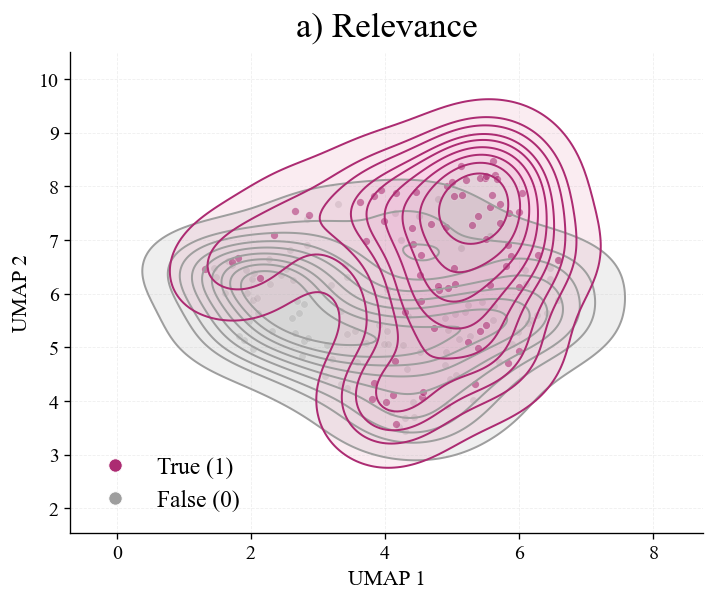

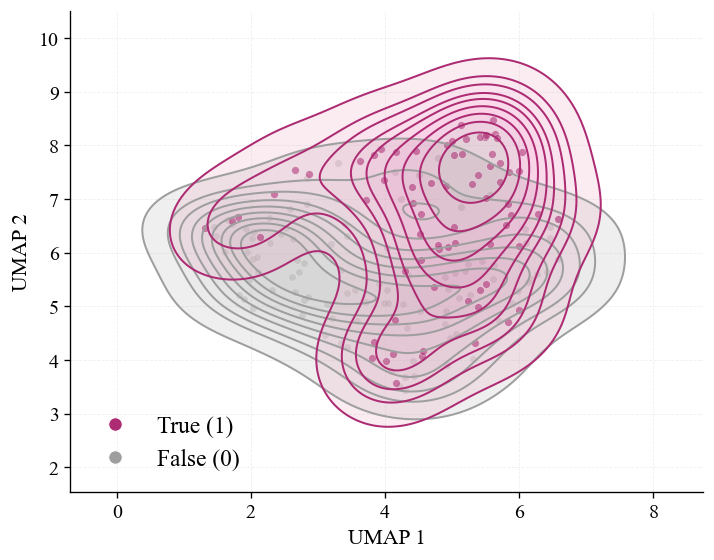

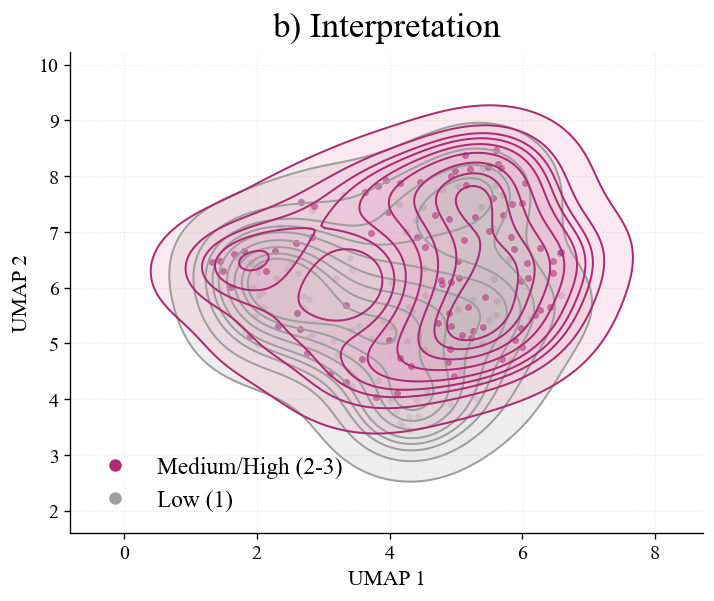

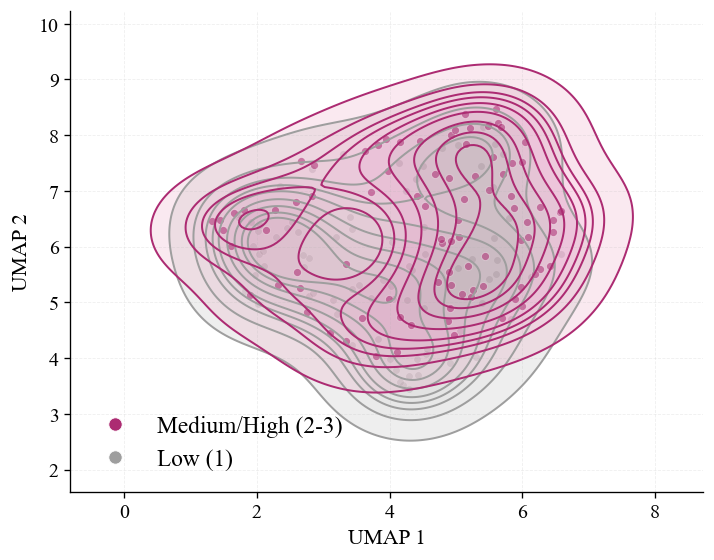

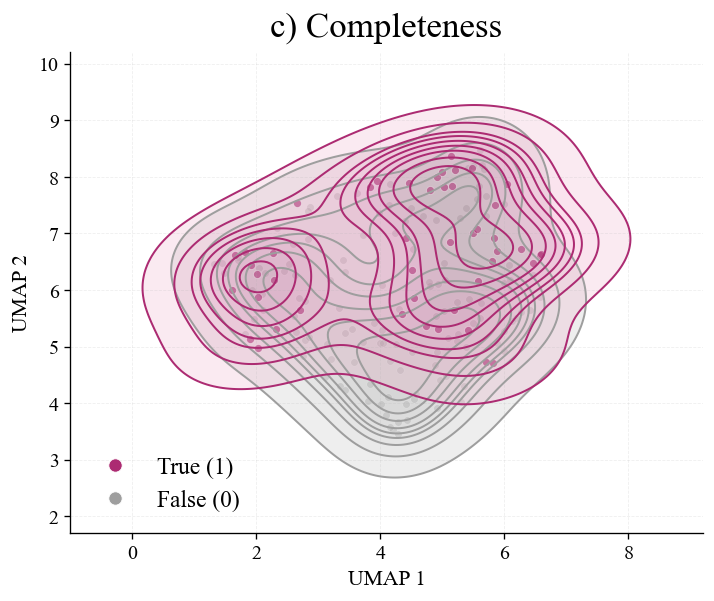

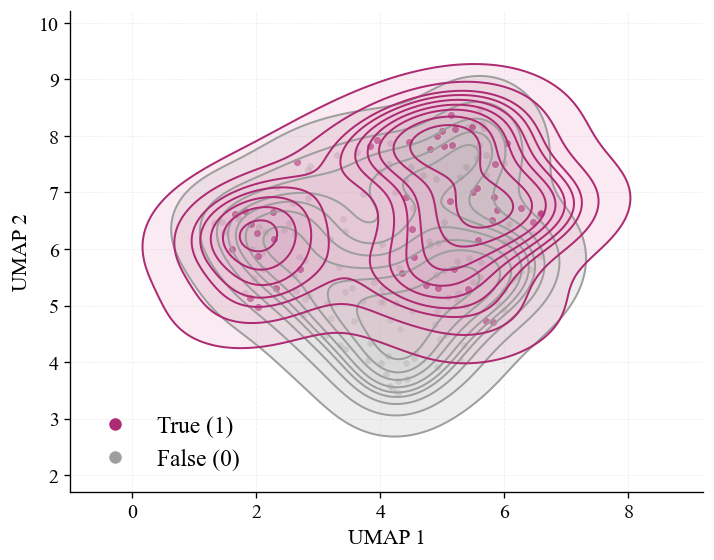

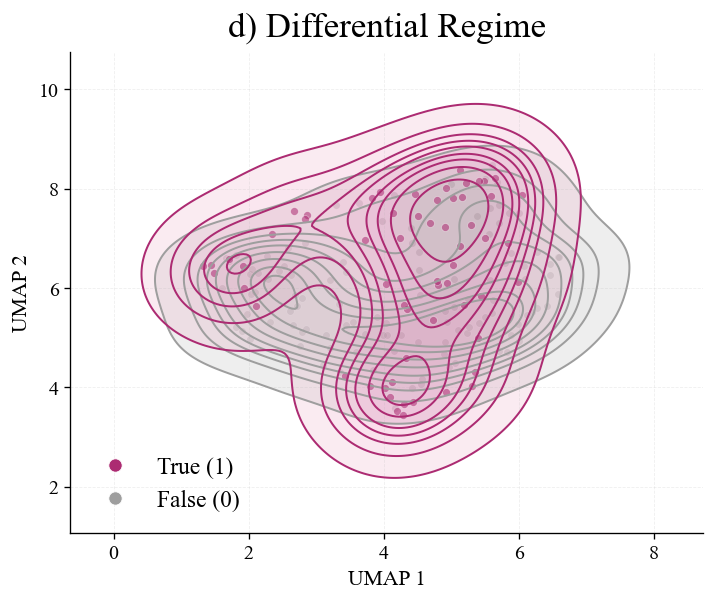

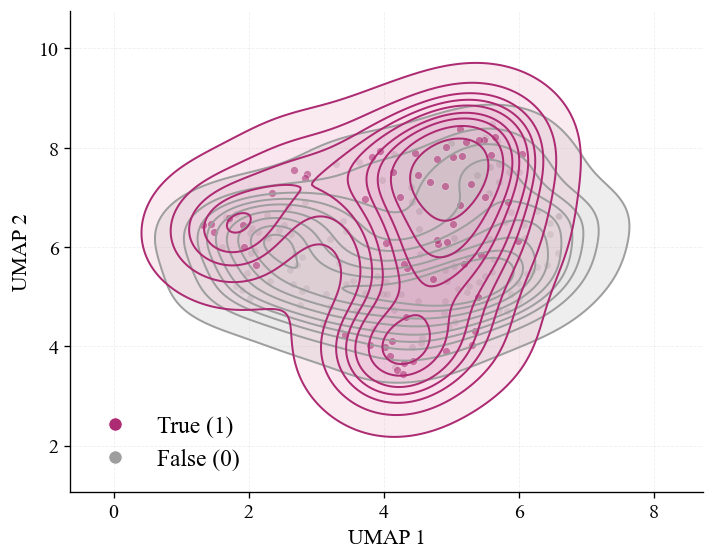

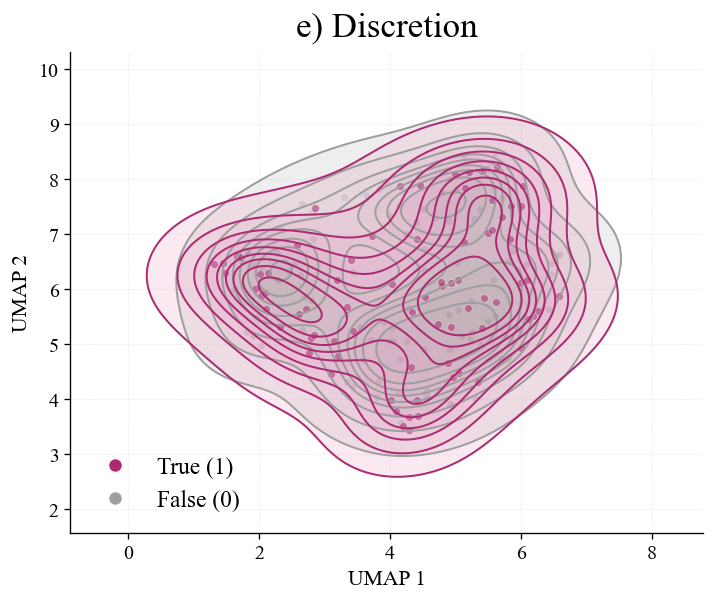

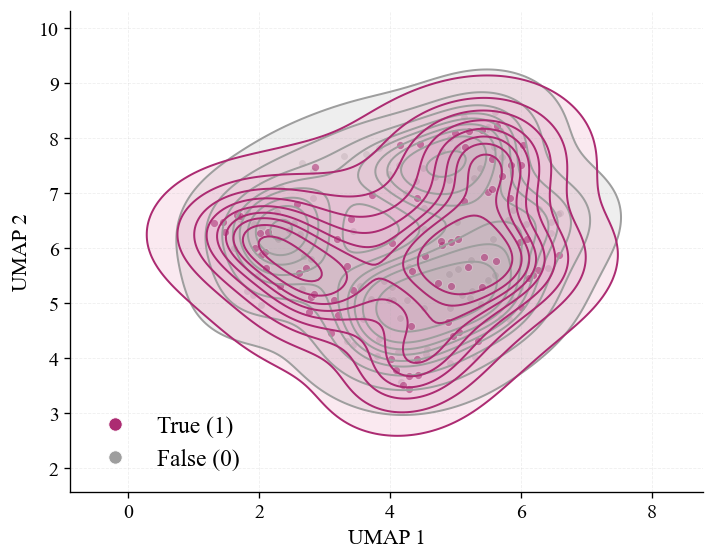

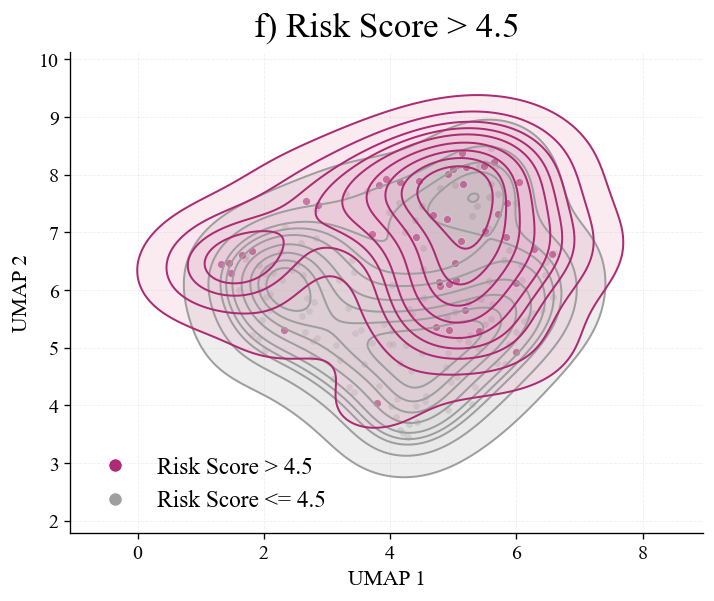

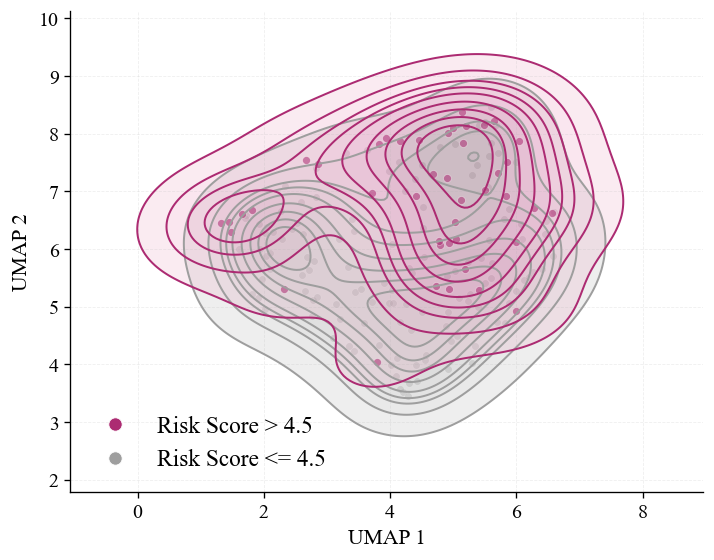

,file_name,target,display_target,variant,rows,n_color,n_gray,png,svg,pdf
0,kde_data__Relevance.csv,Relevance,Relevance,with_title,169,72,97,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
1,kde_data__Relevance.csv,Relevance,Relevance,without_title,169,72,97,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
2,kde_data__Interpretability.csv,Interpretability,Interpretation,with_title,169,88,81,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
3,kde_data__Interpretability.csv,Interpretability,Interpretation,without_title,169,88,81,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
4,kde_data__Completeness.csv,Completeness,Completeness,with_title,169,47,122,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
5,kde_data__Completeness.csv,Completeness,Completeness,without_title,169,47,122,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
6,kde_data__Differential_Regime.csv,Differential Regime,Differential Regime,with_title,169,60,109,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
7,kde_data__Differential_Regime.csv,Differential Regime,Differential Regime,without_title,169,60,109,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
8,kde_data__Discretionality.csv,Discretionality,Discretion,with_title,169,76,93,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
9,kde_data__Discretionality.csv,Discretionality,Discretion,without_title,169,76,93,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...


In [15]:
export_rows = []

for file_name in ORDERED_KDE_FILES:
    path = resolve_kde_file(file_name)
    meta = build_meta(file_name)
    df_plot = prepare_kde_dataframe(meta)

    for variant, show_title in [("with_title", True), ("without_title", False)]:
        fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
        plot_kde_umap(df_plot, meta, ax=ax, show_title=show_title, legend_loc="lower left")

        stem = f"{meta['base_stem']}__{variant}"
        png_path, svg_path, pdf_path = save_figure(fig, stem)
        plt.show()
        plt.close(fig)

        export_rows.append({
            "file_name": file_name,
            "target": meta["target_name"],
            "display_target": display_name(meta["target_name"]),
            "variant": variant,
            "rows": len(df_plot),
            "n_color": int((df_plot['group_key'] == 'color').sum()),
            "n_gray": int((df_plot['group_key'] == 'gray').sum()),
            "png": str(png_path),
            "svg": str(svg_path),
            "pdf": str(pdf_path),
        })

kde_export_log = pd.DataFrame(export_rows)
kde_export_log

## 5) Reproducibility Log

In [16]:
kde_export_log = kde_export_log.copy()
kde_export_log["source_path"] = kde_export_log["file_name"].apply(lambda x: str(resolve_kde_file(x)))

log_path = OUTPUT_DIR / "paper_kde_export_log.csv"
kde_export_log.to_csv(log_path, index=False)

print("Saved reproducibility log:", log_path)
kde_export_log

Saved reproducibility log: C:\Users\57305\OneDrive - Universidad Nacional de Colombia\Documentos\GitHub\JURISIN_2026\JURISIN-2026\Version 2\paper_figures\kde\paper_kde_export_log.csv


,file_name,target,display_target,variant,rows,n_color,n_gray,png,svg,pdf,source_path
0,kde_data__Relevance.csv,Relevance,Relevance,with_title,169,72,97,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
1,kde_data__Relevance.csv,Relevance,Relevance,without_title,169,72,97,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
2,kde_data__Interpretability.csv,Interpretability,Interpretation,with_title,169,88,81,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
3,kde_data__Interpretability.csv,Interpretability,Interpretation,without_title,169,88,81,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
4,kde_data__Completeness.csv,Completeness,Completeness,with_title,169,47,122,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
5,kde_data__Completeness.csv,Completeness,Completeness,without_title,169,47,122,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
6,kde_data__Differential_Regime.csv,Differential Regime,Differential Regime,with_title,169,60,109,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
7,kde_data__Differential_Regime.csv,Differential Regime,Differential Regime,without_title,169,60,109,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
8,kde_data__Discretionality.csv,Discretionality,Discretion,with_title,169,76,93,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
9,kde_data__Discretionality.csv,Discretionality,Discretion,without_title,169,76,93,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...,C:\Users\57305\OneDrive - Universidad Nacional...
